# Universidad de Buenos Aires
# Vision por Computadora II


#### Librerias

In [1]:
import gdown
import zipfile
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

import cv2
from PIL import Image

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# **CLASIFICADOR DE EMOCIONES**

In [2]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=3fd2b44f-ce89-4f77-9279-fca56a04838f
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 32.0MB/s]


In [3]:
url = "https://drive.google.com/uc?id=1iHmMN81lHFbimo0RqXlvjzyjqOMOXrbS"
output = "prueba.zip"

gdown.download(url, output, quiet=False)

destino = "prueba"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

Downloading...
From: https://drive.google.com/uc?id=1iHmMN81lHFbimo0RqXlvjzyjqOMOXrbS
To: /content/prueba.zip
100%|██████████| 2.20M/2.20M [00:00<00:00, 12.5MB/s]


In [4]:
url = "https://drive.google.com/uc?id=1ug9uZq_dG9_FUlFg5HI7WnUwrRaHuCjK"
output = "modelo_completo.pth"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ug9uZq_dG9_FUlFg5HI7WnUwrRaHuCjK
To: /content/modelo_completo.pth
100%|██████████| 1.22M/1.22M [00:00<00:00, 10.1MB/s]


'modelo_completo.pth'

## 1. Preprocesamiento de Datos

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento


### Transformaciones a aplicar

#### Preprocesamiento

* **Grayscale**: Conversión a escala de grises. El color de las imagenes no es informativo para este caso y reduce la complejidad del modelo.

* **Resize**: Conversión a 48x48 pixels. Es una resolución estándar que conserva la información facial mientras reduce complejidad.

#### Data augmentation

Se aplican solo en entrenamiento y de forma aleatoria, generando variaciones de la imagen original al solicitarla.

* **RandomHorizontalFlip(p=0.5)**: Refleja la imagen horizontalmente.

* **RandomRotation(15)**: Rota la imagen dentro de un rango de ±15°.

* **ColorJitter(brightness=0.1, contrast=0.1)**: Introduce variaciones leves de iluminación.

#### Transformación a tensores

* **ToTensor()**: Convierte la imagen a tensores usados por PyTorch.

#### Normalización

* **Normalize(mean=[0.5], std=[0.5])**: Normaliza la imagen con media y desviación estándar para estabilizar el entrenamiento.

In [5]:
# Transformaciones para train

train_transforms = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48,48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomCrop(48, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Transformaciones para test

test_transforms = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48,48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Carga de los datos

train_data = datasets.ImageFolder('./datos_zip/dataset_emociones/train', transform=train_transforms)
test_data  = datasets.ImageFolder('./datos_zip/dataset_emociones/validation',  transform=test_transforms)

print(f'Mapeo de clases a índices: {train_data.class_to_idx}')

# Mostrar distribución real
labels = [label for _, label in train_data.samples]
conteo = Counter(labels)
print("\nCantidad de imágenes por clase:")
for idx, count in conteo.items():
    print(f"{train_data.classes[idx]} : {count}")

Mapeo de clases a índices: {'alegria': 0, 'disgusto': 1, 'enojo': 2, 'miedo': 3, 'seriedad': 4, 'sorpresa': 5, 'tristeza': 6}

Cantidad de imágenes por clase:
alegria : 4772
disgusto : 717
enojo : 705
miedo : 281
seriedad : 2524
sorpresa : 1290
tristeza : 1982


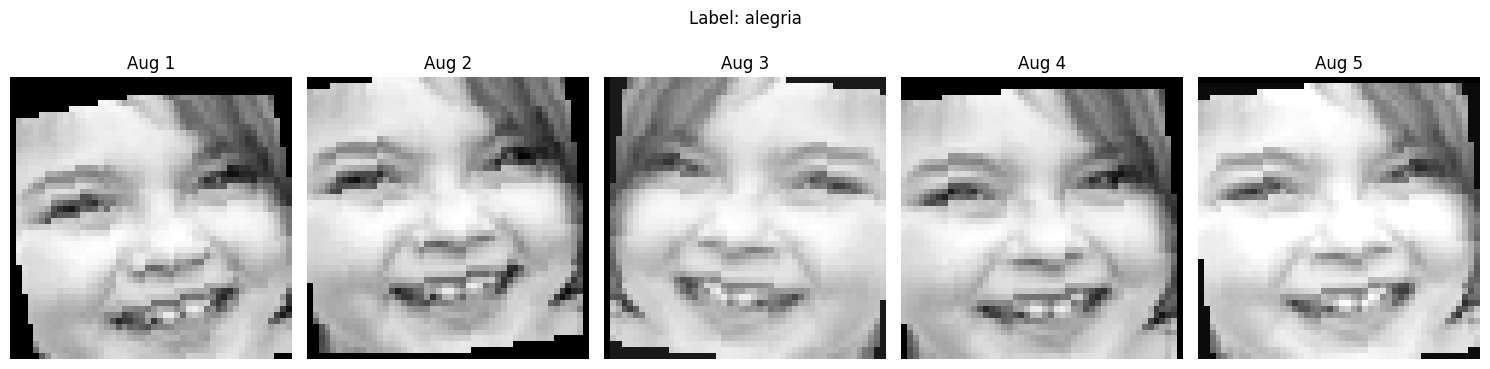

In [6]:
# Visualización de augmentations

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

# Obtiene 5 veces la misma imagen con augmentations diferentes

for i in range(5):

    img, label = train_data[500]
    img = img * 0.5 + 0.5          # Desnormaliza la imagen
    img_np = img.squeeze().numpy() # Quitar canal si es 1 solo (grayscale)

    axes[i].imshow(img_np, cmap="gray")
    axes[i].set_title(f"Aug {i+1}")
    axes[i].axis("off")

plt.suptitle(f"Label: {train_data.classes[label]}")
plt.tight_layout()
plt.show()

## 2. Construcción y entrenamiento del Modelo CNN

#### Bloque convolucional

**Capa Conv2d:**
* Aplica filtros (kernels) que extraen patrones locales de la imagen.
    * in_c: cantidad de canales de entrada.
    * out_c: cantidad de canales de salida.
    * k: tamaño del kernel (3x3 por defecto).
    * padding='same': mantiene el tamaño espacial de la imagen.
    * bias=False: se desactiva el bias porque se utiliza BatchNorm.

**Capa BatchNorm2d**
* Normaliza la activación de cada canal para estabilizar el entrenamiento,
    * out_c: cantidad de canales.

**Capa ReLU:**
* Función de activación no lineal. Evita saturación que puede producirse con tanh.

In [7]:
# Bloque convolucional

def conv_block(in_c, out_c, k=3):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=k, padding='same', bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )

#### Modelo

Se aplican tres bloques duplicando canales y reduciendo resolución a la mitas.  
En cada bloque se aplican dos convoluciones seguidas (la segunda convolución mejoró mucho las métricas finales de evaluación).  
La capa de Global Pooling Average convierte cada mapa final en un solo número.  
Dropout evita overfiting.  
Clasificador final a las 7 clases.  

In [8]:
# Modelo

class CNN(nn.Module):
    def __init__(self, n_channels=1, n_outputs=7):
        super().__init__()

        # Bloque 1 – salida: 32 canales, resolución 48x48 → 24x24
        self.b1 = nn.Sequential(
            conv_block(n_channels, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2)   # Reduce resolución a la mitad
        )

        # Bloque 2 – salida: 64 canales, resolución 24x24 → 12x12
        self.b2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2)
        )

        # Bloque 3 – salida: 128 canales, resolución 12x12 → 6x6
        self.b3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling: convierte 128 x 6 x 6 → 128 x 1 x 1
        # Resume toda la información espacial en un vector por canal.
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Dropout para reducir overfitting.
        self.dropout = nn.Dropout(0.4)

        # Capa totalmente conectada (clasificador final)
        self.fc = nn.Linear(128, n_outputs)

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)

        x = self.gap(x)         # GAP → 128x1x1
        x = x.flatten(1)        # Aplana → 128
        x = self.dropout(x)     # Dropout antes del clasificador

        return self.fc(x)


model = CNN()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


## 3. Evaluación del Modelo



#### Data Loaders

Se emplea un sampler balanceado en entrenamiento para compensar el desbalance de las clases minoritarias (disgusto, enojo y miedo).

COMENTARIO: Esto mejoró mucho las métricas de precisión y recall de estas clases minoritarias luego del entrenamiento.

In [9]:
# Etiquetas como array

labels_np = np.array(labels)

# Conteo por clase

class_counts = np.bincount(labels_np)

# Pesos por clase (menos muestras = más peso)

class_weights = 1.0 / class_counts

# Peso por muestra

sample_weights = class_weights[labels_np]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Creación de los dataloaders

train_loader = DataLoader(
    train_data,
    batch_size=64,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#### Entrenamiento

LOAD_MODEL = True / False permite cargar el modelo ya entrenado con sus métricas o bien entrenar de cero nuevamente.

Se aplica un scheduler para reducir el tiempo de entrenamiento iniciando con un learning rate mayor e ir reduciendolo cuando no mejora, reduciendo tambien el ruido de las métricas de evaluación.

La cantidad de épocas se ajusto al punto en el que ya no se observa mejora de las métricas.

In [10]:
# Permite cargar un modelo ya entrenado o entrenar nuevo

LOAD_MODEL = True
PATH = "modelo_completo.pth"

# Carga modelo entrenado y métricas si existe

if LOAD_MODEL and os.path.exists(PATH):

    checkpoint = torch.load(PATH, map_location=torch.device("cpu"), weights_only=False)

    model.load_state_dict(checkpoint["model_state"])

    train_loss_list = checkpoint["train_loss"]
    val_loss_list   = checkpoint["val_loss"]
    train_acc_list  = checkpoint["train_acc"]
    val_acc_list    = checkpoint["val_acc"]
    train_f1_list   = checkpoint["train_f1"]
    val_f1_list     = checkpoint["val_f1"]
    lr_list         = checkpoint["lr"]
    class_names     = checkpoint["class_names"]
    y_true_best = checkpoint["y_true_best"]
    y_pred_best = checkpoint["y_pred_best"]
    val_loss_best = checkpoint["val_loss_best"]
    val_acc_best  = checkpoint["val_acc_best"]
    val_f1_best   = checkpoint["val_f1_best"]

    print("Modelo cargado correctamente.")

# Entrena modelo

else:

    print("Entrenando modelo.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Usando dispositivo:", device)

    # Lleva el modelo al dispositivo

    model = model.to(device)

    # Épocas de entrenamiento

    num_epochs = 50

    # Listas de métrica

    train_loss_list = []
    val_loss_list   = []
    train_acc_list  = []
    val_acc_list    = []
    train_f1_list   = []
    val_f1_list     = []
    lr_list         = []

    # Mejor modelo

    best_val_loss = float("inf")
    best_model_state = None

    # Scheduler

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )

    # Loop de épocas

    for epoch in range(num_epochs):

        # Entrenamiento

        model.train()
        train_loss = 0
        y_true_train, y_pred_train = [], []

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(dim=1)

            y_true_train.append(y)
            y_pred_train.append(preds)

        y_true_train = torch.cat(y_true_train).cpu().numpy()
        y_pred_train = torch.cat(y_pred_train).cpu().numpy()

        train_loss /= len(train_loader)
        train_acc = accuracy_score(y_true_train, y_pred_train)
        train_f1  = f1_score(y_true_train, y_pred_train, average="macro")

        # Validación

        model.eval()
        val_loss = 0
        y_true_val, y_pred_val = [], []

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)

                outputs = model(X)
                loss = criterion(outputs, y)

                val_loss += loss.item()
                preds = outputs.argmax(dim=1)

                y_true_val.append(y)
                y_pred_val.append(preds)

        y_true_val = torch.cat(y_true_val).cpu().numpy()
        y_pred_val = torch.cat(y_pred_val).cpu().numpy()

        val_loss /= len(test_loader)
        val_acc = accuracy_score(y_true_val, y_pred_val)
        val_f1  = f1_score(y_true_val, y_pred_val, average="macro")

        # Paso del scheduler

        scheduler.step(val_loss)

        # Guarda el mejor modelo

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            y_true_best = y_true_val.copy()
            y_pred_best = y_pred_val.copy()
            val_loss_best = val_loss
            val_acc_best  = val_acc
            val_f1_best   = val_f1

        # Paso del scheduler

        scheduler.step(val_loss)

        # Guarda métricas

        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_f1_list.append(train_f1)
        val_f1_list.append(val_f1)
        lr_list.append(optimizer.param_groups[0]["lr"])

        # Log

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f} | "
            f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f} | "
            f"Train F1={train_f1:.4f}, Val F1={val_f1:.4f} | "
            f"LR={optimizer.param_groups[0]['lr']:.6f}"
        )

    # Restaura el mejor modelo (mínimo loss de validación)

    model.load_state_dict(best_model_state)

    print("Modelo restaurado al menor val_loss.")

    # Guarda en disco el modelo entrenado y las métricas

    class_names = train_data.classes

    torch.save({
        "model_state": model.state_dict(),
        "train_loss": train_loss_list,
        "val_loss": val_loss_list,
        "train_acc": train_acc_list,
        "val_acc": val_acc_list,
        "train_f1": train_f1_list,
        "val_f1": val_f1_list,
        "lr": lr_list,
        "class_names": train_data.classes,
        "y_true_best": y_true_best,
        "y_pred_best": y_pred_best,
        "val_loss_best": val_loss_best,
        "val_acc_best": val_acc_best,
        "val_f1_best": val_f1_best
    }, "modelo_completo.pth")

    print("Modelo y métricas guardados como modelo_completo.pth")

# Imprimir métricas del mejor modelo

print("\nMétricas globales del Modelo:")
print(f"Accuracy: {val_acc_best:.4f}")
print(f"F1 Score:  {val_f1_best:.4f}")


Modelo cargado correctamente.

Métricas globales del Modelo:
Accuracy: 0.7611
F1 Score:  0.6825


#### Gráficas de evolución de métricas y pérdida

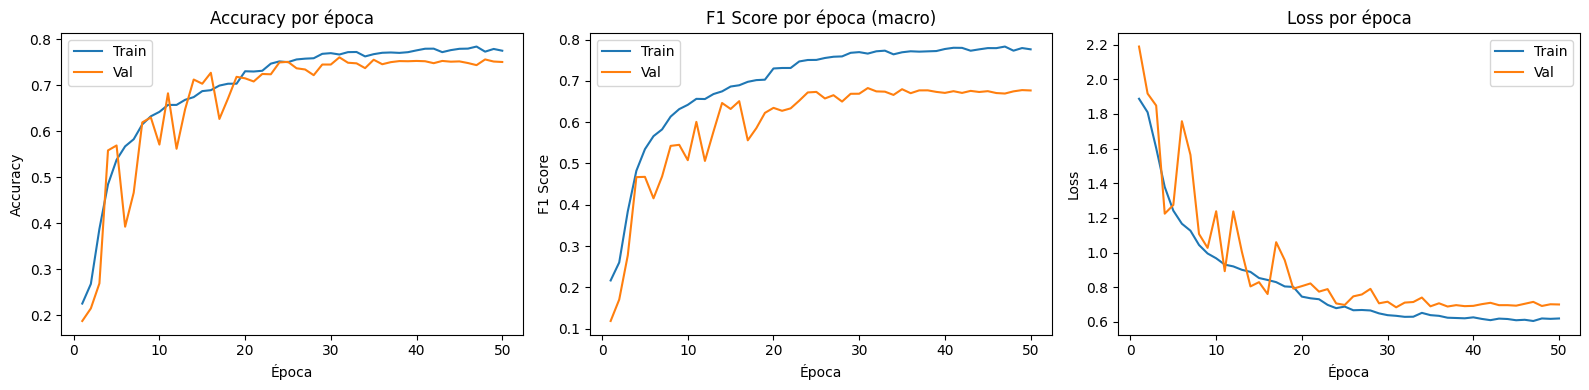

In [11]:
epochs = range(1, len(train_loss_list)+1)

plt.figure(figsize=(16,4))

# Accuracy

plt.subplot(1, 3, 1)
plt.plot(epochs, train_acc_list, label="Train")
plt.plot(epochs, val_acc_list, label="Val")
plt.title("Accuracy por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

# F1 Score

plt.subplot(1, 3, 2)
plt.plot(epochs, train_f1_list, label="Train")
plt.plot(epochs, val_f1_list, label="Val")
plt.title("F1 Score por época (macro)")
plt.xlabel("Época")
plt.ylabel("F1 Score")
plt.legend()

# Loss

plt.subplot(1, 3, 3)
plt.plot(epochs, train_loss_list, label="Train")
plt.plot(epochs, val_loss_list, label="Val")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

#### Reporte de clasificación

Las peores métricas se dan en las tres clases minoritarias, aunque mejoraron mucho luego de varios ajustes del modelo (dataloader balanceado en entrenamiento y segunda capa de convolución en cada bloque).

In [12]:
print("Reporte clasidicación (Validación)\n")
print(classification_report(y_true_best, y_pred_best, target_names=class_names))

Reporte clasidicación (Validación)

              precision    recall  f1-score   support

     alegria       0.93      0.83      0.88      1185
    disgusto       0.45      0.47      0.46       160
       enojo       0.65      0.78      0.71       162
       miedo       0.45      0.69      0.55        74
    seriedad       0.71      0.75      0.73       680
    sorpresa       0.72      0.82      0.77       329
    tristeza       0.72      0.66      0.69       478

    accuracy                           0.76      3068
   macro avg       0.66      0.72      0.68      3068
weighted avg       0.78      0.76      0.77      3068



#### Matrices de Confusión

Matrices de confusión (Validación)



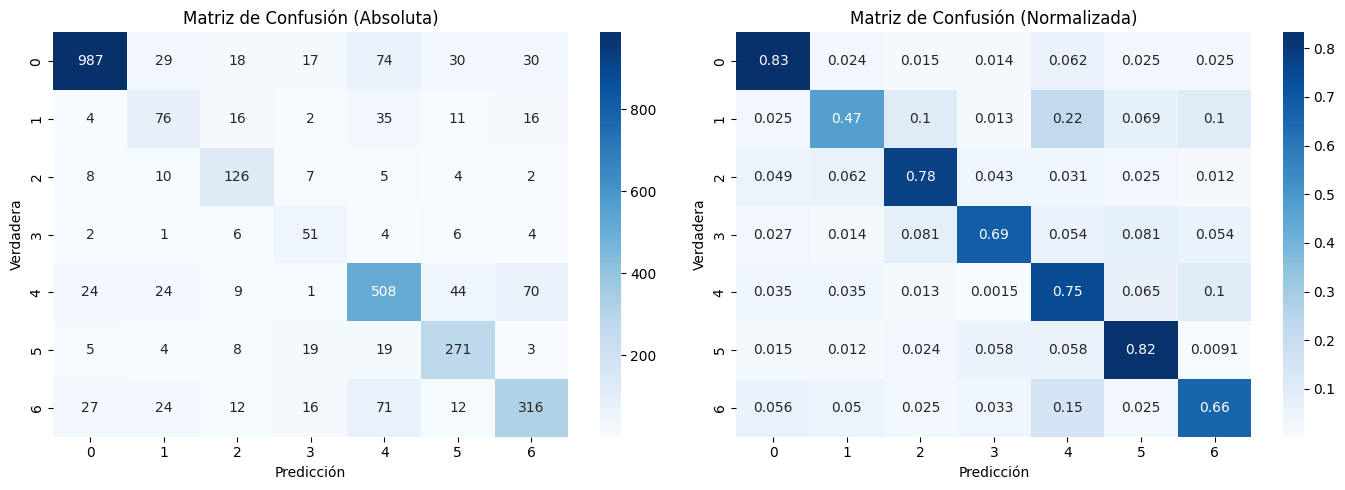

In [13]:
print("Matrices de confusión (Validación)\n")

cm_abs = confusion_matrix(y_true_best, y_pred_best)
cm_norm = cm_abs.astype("float") / cm_abs.sum(axis=1, keepdims=True)

plt.figure(figsize=(14,5))

# Absoluta

plt.subplot(1,2,1)
sns.heatmap(cm_abs, annot=True, fmt='d', cmap="Blues")
plt.title("Matriz de Confusión (Absoluta)")
plt.xlabel("Predicción")
plt.ylabel("Verdadera")

# Normalizada

plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, cmap="Blues")
plt.title("Matriz de Confusión (Normalizada)")
plt.xlabel("Predicción")
plt.ylabel("Verdadera")

plt.tight_layout()
plt.show()

 ## 4. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional


In [14]:
def predict_image2(model, img_path, class_names):

    model.eval()
    device = next(model.parameters()).device

    # Carga imagen original

    img_orig = Image.open(img_path).convert("RGB")
    img_cv = cv2.cvtColor(np.array(img_orig), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

    # Detección de rostro

    haar_path = os.path.join(
        os.path.dirname(cv2.__file__), "data", "haarcascade_frontalface_default.xml"
    )
    face_cascade = cv2.CascadeClassifier(haar_path)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

    det_img = img_cv.copy()
    cropped_face_rgb = None
    cropped_face_pil = None

    if len(faces) > 0:
        (x, y, w, h) = faces[0]

        # Ajustes del recorte

        shrink_ratio = 0.80     # achicar
        shift_ratio  = 0.10    # bajar hacia la pera

        side = int(min(w, h) * shrink_ratio)

        # Centro del bounding box original

        cx, cy = x + w//2, y + h//2

        # Desplazar hacia abajo

        cy = cy + int(side * shift_ratio)

        half = side // 2

        # Coordenadas finales del recorte

        x1 = max(cx - half, 0)
        y1 = max(cy - half, 0)
        x2 = min(cx + half, img_cv.shape[1])
        y2 = min(cy + half, img_cv.shape[0])

        # Dibujar sel marco

        cv2.rectangle(det_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Recorte enviado al modelo

        cropped = img_cv[y1:y2, x1:x2]
        cropped_face_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

        # Convertir recorte a PIL

        cropped_face_pil = Image.fromarray(cropped_face_rgb)

    else:
        raise ValueError("No se detectó ningún rostro en la imagen.")

    det_img_rgb = cv2.cvtColor(det_img, cv2.COLOR_BGR2RGB)

    # Preprocesamiento

    img_tensor = test_transforms(cropped_face_pil)
    img_input = img_tensor.unsqueeze(0).to(device)

    # Predicción

    with torch.no_grad():
        logits = model(img_input)
        probs = F.softmax(logits, dim=1)[0].cpu()

    winner_idx = torch.argmax(probs).item()
    winner_class = class_names[winner_idx]

    # Visualización

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(det_img_rgb)
    axes[0].set_title("Imagen Original + Detección")
    axes[0].axis("off")

    axes[1].imshow(cropped_face_rgb)
    axes[1].set_title("Rostro Recortado (1:1)")
    axes[1].axis("off")

    axes[2].imshow(img_tensor.squeeze().numpy(), cmap="gray")
    axes[2].set_title("Rostro Preprocesado")
    axes[2].axis("off")

    plt.suptitle(os.path.basename(img_path))
    plt.show()

    # Probabilidades

    print("Probabilidad por clase:")
    for i, cls in enumerate(class_names):
        print(f"{cls:15s}: {probs[i].item():.4f}")

    print("\nClase predicha:")
    print(f"{winner_class}  ({probs[winner_idx].item():.4f})")

    return winner_class, probs





## 5. Predicción de Sentimiento en Video Promedio

In [15]:
import cv2
import math
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from collections import Counter

In [17]:
video_url_for_test = "https://drive.google.com/file/d/1WKfnz_FR6bc9mmqa4SVXRXrOVP3SQVCK/view?usp=sharing"
video_filename_for_test = "videoplayback.mp4"

if not os.path.exists(video_filename_for_test):
    print(f'Descargando {video_filename_for_test}...')
    gdown.download(url=video_url_for_test, output=video_filename_for_test, fuzzy=True, quiet=False)

video_test = video_filename_for_test

Descargando videoplayback.mp4...


Downloading...
From: https://drive.google.com/uc?id=1WKfnz_FR6bc9mmqa4SVXRXrOVP3SQVCK
To: /content/videoplayback.mp4
100%|██████████| 9.91M/9.91M [00:00<00:00, 53.7MB/s]


In [18]:
#Nueva prueba con otro video:
def analizar_sentimiento_video(video_path, model, class_names, fps_extraer=1):
    """
    Extrae fotogramas de un video y utiliza la CNN para emitir el sentimiento promedio general.
    """
    model.eval()
    device = next(model.parameters()).device

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error al abrir el video: {video_path}")
        return None, None

    fps_original = cap.get(cv2.CAP_PROP_FPS)
    if fps_original == 0: fps_original = 30
    print(f"► Procesando: {video_path.split('/')[-1]} | Fotogramas extraídos p/seg: {fps_extraer}")

    frame_interval = max(1, int(math.floor(fps_original / fps_extraer)))
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    fotograma_actual = 0
    predicciones_totales = []

    while True:
        ret, frame = cap.read()
        if not ret: break

        if fotograma_actual % frame_interval == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

            if len(faces) > 0:
                (x, y, w, h) = faces[0]
                shrink_ratio, shift_ratio = 0.80, 0.10
                side = int(min(w, h) * shrink_ratio)
                cx, cy = x + w//2, y + h//2
                cy += int(side * shift_ratio)
                half = side // 2

                x1, y1 = max(cx - half, 0), max(cy - half, 0)
                x2, y2 = min(cx + half, frame.shape[1]), min(cy + half, frame.shape[0])

                cropped = frame[y1:y2, x1:x2]
                cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
                cropped_pil = Image.fromarray(cropped_rgb)

                img_tensor = test_transforms(cropped_pil)
                img_input = img_tensor.unsqueeze(0).to(device)

                with torch.no_grad():
                    logits = model(img_input)
                    probs = F.softmax(logits, dim=1)[0].cpu()

                winner_idx = torch.argmax(probs).item()
                predicciones_totales.append(class_names[winner_idx])

        fotograma_actual += 1

    cap.release()

    if not predicciones_totales:
        print("No se detectaron rostros con claridad en el video.")
        return None, None

    conteo = Counter(predicciones_totales)

    print(f"\n--- [ RESULTADOS DEL ANÁLISIS DEL VIDEO ] ---")
    for sentimiento, frecuencia in conteo.most_common():
        print(f" - {sentimiento}: {frecuencia} cuadros ({(frecuencia/len(predicciones_totales))*100:.1f}%)")

    sentimiento_predominante = conteo.most_common(1)[0][0]
    print(f"\n⭐⭐ SENTIMIENTO DOMINANTE EN VIDEO: {sentimiento_predominante.upper()} ⭐⭐")

    return sentimiento_predominante, conteo

# EJECUCIÓN
video = video_test
sentimiento_final, estadisticas = analizar_sentimiento_video(video, model, class_names, fps_extraer=1)


► Procesando: videoplayback.mp4 | Fotogramas extraídos p/seg: 1

--- [ RESULTADOS DEL ANÁLISIS DEL VIDEO ] ---
 - alegria: 319 cuadros (92.5%)
 - sorpresa: 14 cuadros (4.1%)
 - seriedad: 9 cuadros (2.6%)
 - tristeza: 3 cuadros (0.9%)

⭐⭐ SENTIMIENTO DOMINANTE EN VIDEO: ALEGRIA ⭐⭐


## 7. Análisis Temporal de Emociones

En esta sección evolucionamos el análisis de video: en lugar de un único porcentaje de sentimiento promedio, rastreamos **cada emoción en el tiempo** para construir una *curva de temperatura emocional*.

Cambios respecto a la sección anterior:
- **Detección de caras:** se reemplaza Haar Cascade por **YOLOv8** (mayor precisión, menos falsos positivos)
- **Salida temporal:** cada frame analizado genera un registro `{timestamp, emoción, probabilidades}`
- **Suavizado:** rolling average sobre las probabilidades para reducir ruido entre frames
- **Visualización:** figura de 3 paneles con la evolución emocional completa del video

### 7.1 Instalación de dependencias

In [19]:
import importlib

# Instalar ultralytics solo si no está disponible
if importlib.util.find_spec('ultralytics') is None:
    import subprocess
    subprocess.run(['pip', 'install', 'ultralytics', '-q'])

from ultralytics import YOLO
print('ultralytics OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics OK


### 7.2 Detección de caras con YOLO

Se usa `yolov8n-face.pt`, modelo preentrenado de detección de caras. La CNN de emoción no cambia.

In [20]:
from huggingface_hub import hf_hub_download

# Descarga yolov8n-face.pt desde HuggingFace (usa caché local si ya existe)
face_model_path = hf_hub_download(
    repo_id='arnabdhar/YOLOv8-Face-Detection',
    filename='model.pt'
)
yolo_face = YOLO(face_model_path)


def detect_faces_yolo(frame, yolo_model):
    """
    Detecta caras en un frame BGR usando YOLO.
    Retorna lista de recortes BGR ordenados por área descendente (cara más grande primero).
    """
    results = yolo_model(frame, verbose=False)
    crops = []

    for result in results:
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
        sorted_idx = np.argsort(areas)[::-1]  # mayor área primero

        for idx in sorted_idx:
            x1, y1, x2, y2 = map(int, xyxy[idx])
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
            crop = frame[y1:y2, x1:x2]
            if crop.size > 0:
                crops.append(crop)

    return crops


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.pt:   0%|          | 0.00/6.25M [00:00<?, ?B/s]

### 7.3 Extracción temporal de emociones

In [21]:
import cv2
import math
import torch
import torch.nn.functional as F
from PIL import Image


def extract_temporal_emotions(video_path, model, class_names, yolo_model, fps_extract=1):
    """
    Procesa un video frame a frame y retorna una lista de registros temporales.
    Cada registro corresponde a un frame donde se detectó al menos una cara:
        {timestamp_sec, emotion, probs (shape 7), frame_number}
    """
    model.eval()
    device = next(model.parameters()).device

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f'No se pudo abrir el video: {video_path}')

    fps_original = cap.get(cv2.CAP_PROP_FPS)
    if fps_original == 0:
        fps_original = 30

    # Cada cuántos frames originales extraer uno
    frame_interval = max(1, int(math.floor(fps_original / fps_extract)))
    print(f'► Video: {video_path.split("/")[-1]} | FPS original: {fps_original:.1f} | '
          f'Analizando 1 frame cada {frame_interval} frames ({fps_extract} FPS)')

    records = []
    frame_number = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_number % frame_interval == 0:
            timestamp_sec = frame_number / fps_original
            crops = detect_faces_yolo(frame, yolo_model)

            if crops:
                # Usar la cara de mayor área (primera tras el ordenamiento)
                crop_rgb = cv2.cvtColor(crops[0], cv2.COLOR_BGR2RGB)
                crop_pil = Image.fromarray(crop_rgb)

                img_tensor = test_transforms(crop_pil)
                img_input = img_tensor.unsqueeze(0).to(device)

                with torch.no_grad():
                    logits = model(img_input)
                    probs = F.softmax(logits, dim=1)[0].cpu().numpy()

                winner_idx = int(np.argmax(probs))
                records.append({
                    'timestamp_sec': timestamp_sec,
                    'emotion': class_names[winner_idx],
                    'probs': probs,
                    'frame_number': frame_number
                })

        frame_number += 1

    cap.release()
    print(f'✓ {len(records)} frames con rostro detectado de {frame_number} totales')
    return records

### 7.4 Suavizado de la curva

Rolling average centrado sobre los vectores de probabilidad. Reduce el ruido por frames con detección imperfecta.

In [22]:
def smooth_records(records, class_names, window=5):
    """
    Aplica rolling average centrado sobre los vectores de probabilidad.
    Retorna nueva lista con los mismos timestamps pero probs y emotion suavizados.
    """
    if not records:
        return []

    probs_matrix = np.array([r['probs'] for r in records])  # (N, 7)
    smoothed_probs = np.zeros_like(probs_matrix)
    half = window // 2

    for i in range(len(records)):
        start = max(0, i - half)
        end = min(len(records), i + half + 1)
        smoothed_probs[i] = probs_matrix[start:end].mean(axis=0)

    smoothed = []
    for i, r in enumerate(records):
        winner_idx = int(np.argmax(smoothed_probs[i]))
        smoothed.append({
            'timestamp_sec': r['timestamp_sec'],
            'emotion': class_names[winner_idx],
            'probs': smoothed_probs[i],
            'frame_number': r['frame_number']
        })

    return smoothed

### 7.5 Visualización de temperatura emocional

Figura de 3 paneles:
1. **Stacked area chart** — peso emocional acumulado en el tiempo
2. **Scatter** — emoción dominante por frame (crudo + suavizado)
3. **Barras horizontales** — distribución total de emociones

In [23]:
import matplotlib.pyplot as plt
from collections import Counter


def plot_emotional_temperature(records, class_names, smoothed_records=None, title='', save_as=None):
    """
    Genera figura de 3 paneles con la evolución emocional del video.
    Parámetros:
        records          -- salida de extract_temporal_emotions
        class_names      -- lista de nombres de clases (mismo orden que el modelo)
        smoothed_records -- (opcional) salida de smooth_records
        title            -- título de la figura
        save_as          -- ruta donde guardar el PNG (None = no guardar)
    """
    if not records:
        print('No hay registros para visualizar.')
        return

    timestamps = np.array([r['timestamp_sec'] for r in records])
    probs_matrix = np.array([r['probs'] for r in records])  # (N, 7)
    colors = list(plt.cm.tab10.colors[:len(class_names)])
    emotion_to_idx = {e: i for i, e in enumerate(class_names)}

    fig, axes = plt.subplots(3, 1, figsize=(16, 12),
                             gridspec_kw={'height_ratios': [3, 2, 2]})
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    # Panel 1: Stacked area
    ax1 = axes[0]
    ax1.stackplot(timestamps, probs_matrix.T, labels=class_names, colors=colors, alpha=0.8)
    ax1.set_ylabel('Probabilidad acumulada')
    ax1.set_xlim(timestamps[0], timestamps[-1])
    ax1.set_ylim(0, 1)
    ax1.legend(loc='upper right', fontsize=8, ncol=2)
    ax1.set_title('Distribución de emociones en el tiempo')

    # Panel 2: Scatter emoción dominante
    ax2 = axes[1]
    raw_emotions = [r['emotion'] for r in records]
    raw_y = [emotion_to_idx[e] for e in raw_emotions]
    raw_colors = [colors[emotion_to_idx[e]] for e in raw_emotions]
    ax2.scatter(timestamps, raw_y, c=raw_colors, alpha=0.4, s=40, label='Sin suavizar')

    if smoothed_records:
        smooth_emotions = [r['emotion'] for r in smoothed_records]
        smooth_y = [emotion_to_idx[e] for e in smooth_emotions]
        smooth_colors = [colors[emotion_to_idx[e]] for e in smooth_emotions]
        ax2.scatter(timestamps, smooth_y, c=smooth_colors, alpha=1.0, s=20,
                    label='Suavizado', marker='D')
        ax2.legend(loc='upper right', fontsize=8)

    ax2.set_yticks(range(len(class_names)))
    ax2.set_yticklabels(class_names)
    ax2.set_xlim(timestamps[0], timestamps[-1])
    ax2.set_ylabel('Emoción dominante')
    ax2.set_title('Emoción dominante por frame')

    # Panel 3: Distribución total (barras horizontales)
    ax3 = axes[2]
    conteo = Counter(raw_emotions)
    total = len(raw_emotions)
    sorted_items = sorted(conteo.items(), key=lambda x: x[1], reverse=True)
    labels_bar = [e for e, _ in sorted_items]
    counts_bar = [c for _, c in sorted_items]
    bar_colors = [colors[emotion_to_idx[e]] for e in labels_bar]

    bars = ax3.barh(labels_bar, counts_bar, color=bar_colors, edgecolor='white')
    for bar, count in zip(bars, counts_bar):
        pct = count / total * 100
        ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{count} ({pct:.1f}%)', va='center', fontsize=9)

    ax3.set_xlabel('Frames')
    ax3.set_title('Distribución total de emociones')
    ax3.invert_yaxis()

    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
        print(f'Reporte guardado en: {save_as}')

    plt.show()

### 7.6 Demostración

In [35]:
import os
import gdown

# Descarga los videos desde Google Drive si no están en el entorno.
# fuzzy=True maneja la página de confirmación de Drive para archivos grandes.
videos = {
    'videoplayback.mp4':  'https://drive.google.com/file/d/1WKfnz_FR6bc9mmqa4SVXRXrOVP3SQVCK/view?usp=sharing',
    'videoplayback2.mp4': 'https://drive.google.com/file/d/1oISl2aQQwfGOxUt23gDZqi4MmanQZCzn/view?usp=sharing',
    'videoplayback3.mp4': 'https://drive.google.com/file/d/1vVo-xI5qvTvUxrUgHIf1cII3qkN-Slb6/view?usp=sharing',
}
for filename, url in videos.items():
    if not os.path.exists(filename):
        print(f'Descargando {filename}...')
        gdown.download(url=url, output=filename, fuzzy=True, quiet=False)

VIDEO_PATH = 'videoplayback3.mp4'

# Extracción temporal de emociones
records = extract_temporal_emotions(
    VIDEO_PATH, model, class_names, yolo_face, fps_extract=1
)
print('Primer registro:', {k: v if k != 'probs' else v.round(3) for k, v in records[0].items()})


Descargando videoplayback3.mp4...


Downloading...
From: https://drive.google.com/uc?id=1vVo-xI5qvTvUxrUgHIf1cII3qkN-Slb6
To: /content/videoplayback3.mp4
100%|██████████| 3.59M/3.59M [00:00<00:00, 26.4MB/s]


► Video: videoplayback3.mp4 | FPS original: 30.0 | Analizando 1 frame cada 30 frames (1 FPS)
✓ 47 frames con rostro detectado de 1446 totales
Primer registro: {'timestamp_sec': 0.0, 'emotion': 'alegria', 'probs': array([      0.849,       0.003,           0,           0,       0.033,           0,       0.116], dtype=float32), 'frame_number': 0}


In [36]:
# Suavizado con ventana de 5 frames
smoothed = smooth_records(records, class_names, window=5)

assert len(smoothed) == len(records)
print(f'Registros: {len(records)} | Suavizados: {len(smoothed)}')

Registros: 47 | Suavizados: 47


In [37]:
def plot_emotional_temperature_advanced(records, class_names, smoothed_records=None, title="", save_as=None):
    if not records:
        print("No hay registros para visualizar.")
        return

    plot_records = smoothed_records if smoothed_records is not None else records

    timestamps = np.array([r["timestamp_sec"] for r in plot_records])
    probs_matrix = np.array([r["probs"] for r in plot_records])

    confidence = probs_matrix.max(axis=1)
    entropy = -np.sum(probs_matrix * np.log(probs_matrix + 1e-8), axis=1)

    colors = list(plt.cm.tab10.colors[:len(class_names)])
    emotion_to_idx = {e: i for i, e in enumerate(class_names)}

    dominant_emotions = [r["emotion"] for r in plot_records]
    dominant_y = [emotion_to_idx[e] for e in dominant_emotions]
    dominant_colors = [colors[emotion_to_idx[e]] for e in dominant_emotions]

    change_idx = [i for i in range(1, len(dominant_emotions)) if dominant_emotions[i] != dominant_emotions[i - 1]]

    fig, axes = plt.subplots(
        4, 1, figsize=(16, 14),
        gridspec_kw={"height_ratios": [3, 2, 1.5, 1.5]}
    )

    if title:
        fig.suptitle(title, fontsize=15, fontweight="bold")

    # Panel 1: stacked probabilities
    ax1 = axes[0]
    ax1.stackplot(timestamps, probs_matrix.T, labels=class_names, alpha=0.85)
    ax1.set_ylabel("Probabilidad")
    ax1.set_ylim(0, 1)
    ax1.set_title("Distribución temporal de probabilidades")
    ax1.legend(loc="upper right", fontsize=8, ncol=2)
    ax1.grid(alpha=0.25)

    # Panel 2: emoción dominante
    ax2 = axes[1]
    ax2.scatter(timestamps, dominant_y, c=dominant_colors, s=35, alpha=0.85)
    ax2.set_yticks(range(len(class_names)))
    ax2.set_yticklabels(class_names)
    ax2.set_xlabel("Tiempo [s]")
    ax2.set_ylabel("Emoción dominante")
    ax2.set_title("Emoción dominante por instante")
    ax2.grid(alpha=0.25)

    # Panel 3: confianza
    ax3 = axes[2]
    ax3.plot(timestamps, confidence)
    ax3.set_ylim(0, 1)
    ax3.set_xlabel("Tiempo [s]")
    ax3.set_ylabel("Confianza")
    ax3.set_title("Confianza del modelo")
    ax3.grid(alpha=0.25)

    # Panel 4: incertidumbre
    ax4 = axes[3]
    ax4.plot(timestamps, entropy)
    ax4.set_xlabel("Tiempo [s]")
    ax4.set_ylabel("Entropía")
    ax4.set_title("Incertidumbre del modelo")
    ax4.grid(alpha=0.25)

    for idx in change_idx:
        t = timestamps[idx]
        ax2.axvline(t, linestyle="--", alpha=0.15)
        ax3.axvline(t, linestyle="--", alpha=0.10)
        ax4.axvline(t, linestyle="--", alpha=0.10)

    plt.tight_layout()

    if save_as is not None:
        plt.savefig(save_as, dpi=150, bbox_inches="tight")
        print(f"Figura guardada en: {save_as}")

    plt.show()

    counts = Counter(dominant_emotions)
    print("\nResumen del video:")
    for emo, count in counts.most_common():
        print(f"- {emo}: {count} frames")
    print(f"- Confianza promedio: {confidence.mean():.3f}")
    print(f"- Incertidumbre promedio: {entropy.mean():.3f}")

In [38]:
def plot_emotion_heatmap(records, class_names, smoothed_records=None):
    if not records:
        print("No hay registros para visualizar.")
        return

    plot_records = smoothed_records if smoothed_records is not None else records

    timestamps = np.array([r["timestamp_sec"] for r in plot_records])
    probs_matrix = np.array([r["probs"] for r in plot_records])

    plt.figure(figsize=(16, 5))
    plt.imshow(
        probs_matrix.T,
        aspect='auto',
        interpolation='nearest',
        extent=[timestamps[0], timestamps[-1], 0, len(class_names)]
    )
    plt.yticks(np.arange(len(class_names)) + 0.5, class_names)
    plt.colorbar(label='Probabilidad')
    plt.xlabel("Tiempo [s]")
    plt.title("Mapa temporal de probabilidades por emoción")
    plt.show()

Figura guardada en: reporte_emocional_mejorado.png


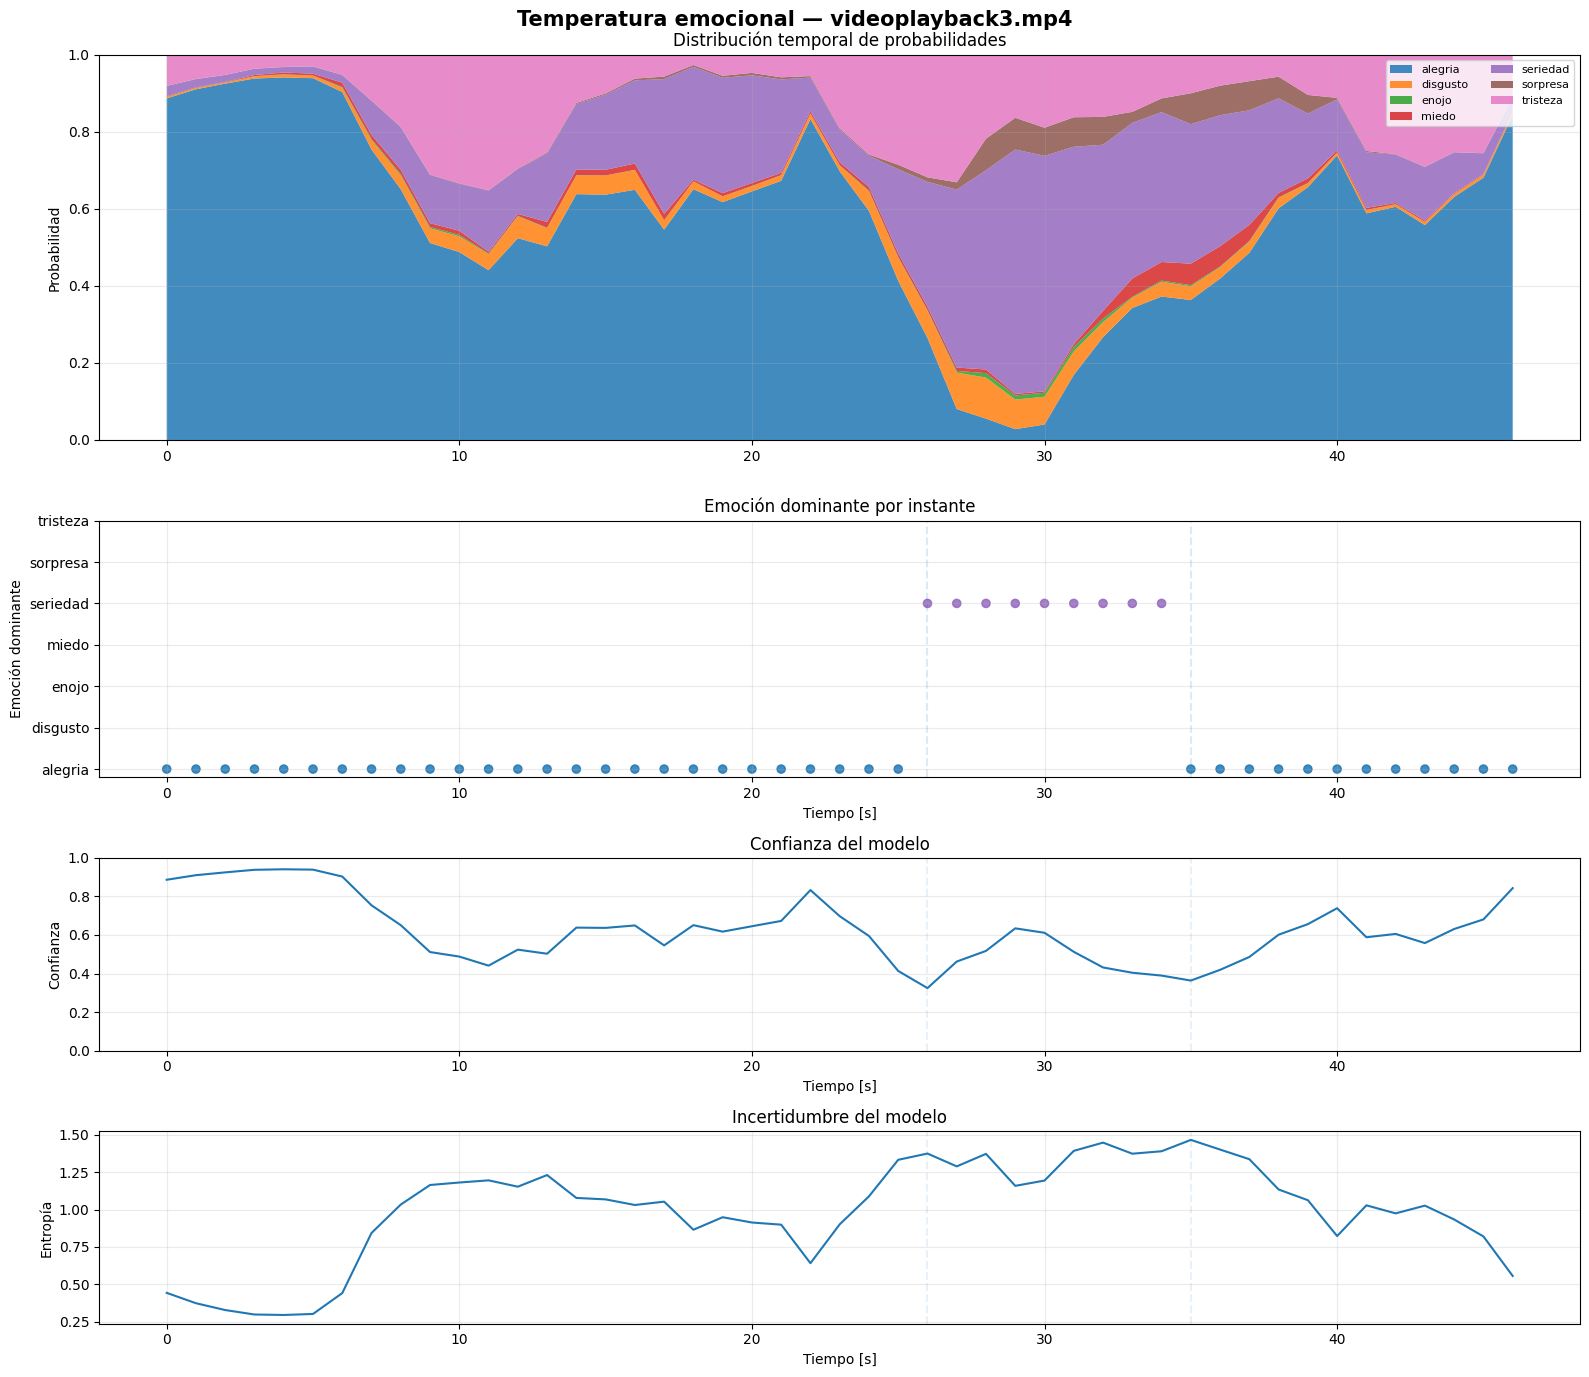


Resumen del video:
- alegria: 38 frames
- seriedad: 9 frames
- Confianza promedio: 0.625
- Incertidumbre promedio: 0.993


In [39]:
plot_emotional_temperature_advanced(
    records=records,
    class_names=class_names,
    smoothed_records=smoothed,
    title=f"Temperatura emocional — {os.path.basename(VIDEO_PATH)}",
    save_as="reporte_emocional_mejorado.png"
)

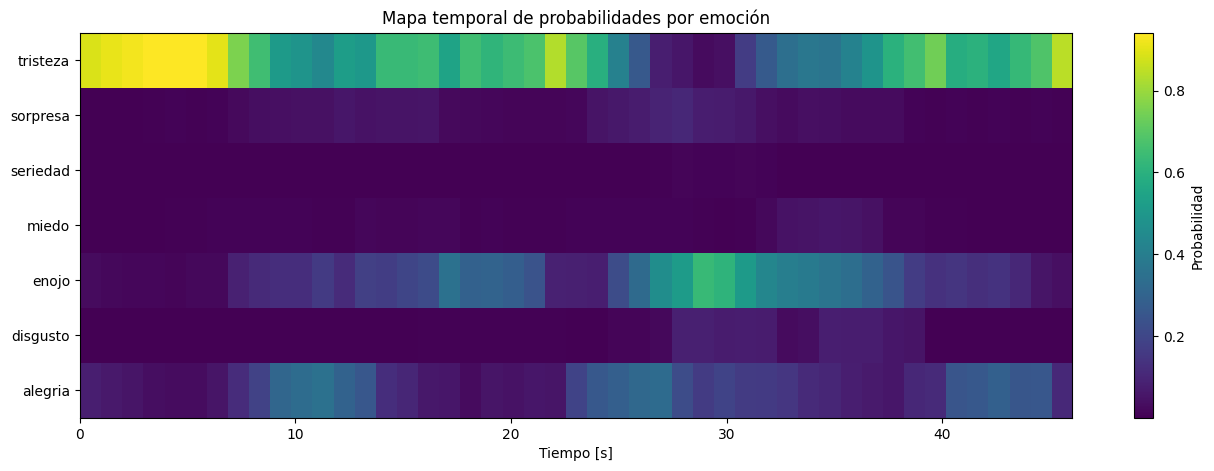

In [40]:
plot_emotion_heatmap(
    records=records,
    class_names=class_names,
    smoothed_records=smoothed
)